In [1]:
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

In [ ]:
def plot_metrics(paths, keys=["train/loss"], align_steps=False):
    if not isinstance(paths, dict):
        paths = {"0": paths}

    eas = {}
    for name, path in paths.items():
        ea = event_accumulator.EventAccumulator(path)
        ea.Reload()
        eas[name] = ea

    n = len(keys)
    cols = 2
    rows = (n + 1) // 2

    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    step_coefs = {}
    if align_steps:
        for name, ea in eas.items():
            scalars = ea.Scalars("train/loss")
            steps = [x.step for x in scalars]
            step_coefs[name] = len(steps)
        for name in step_coefs:
            step_coefs[name] = max(step_coefs.values()) / step_coefs[name]

    for i, key in enumerate(keys):
        try:
            for name, ea in eas.items():
                scalars = ea.Scalars(key)
                steps = [x.step * step_coefs.get(name, 1.) for x in scalars]
                values = [x.value for x in scalars]

                axes[i].plot(steps, values, label=f"{name}[{key}]")
                axes[i].set_xlabel('Step')
                axes[i].set_ylabel('Value')
                axes[i].set_title(key)
                axes[i].legend()
                axes[i].grid(True)
        except Exception:
            pass

    # Скрываем лишние ячейки, если ключей нечётное количество
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

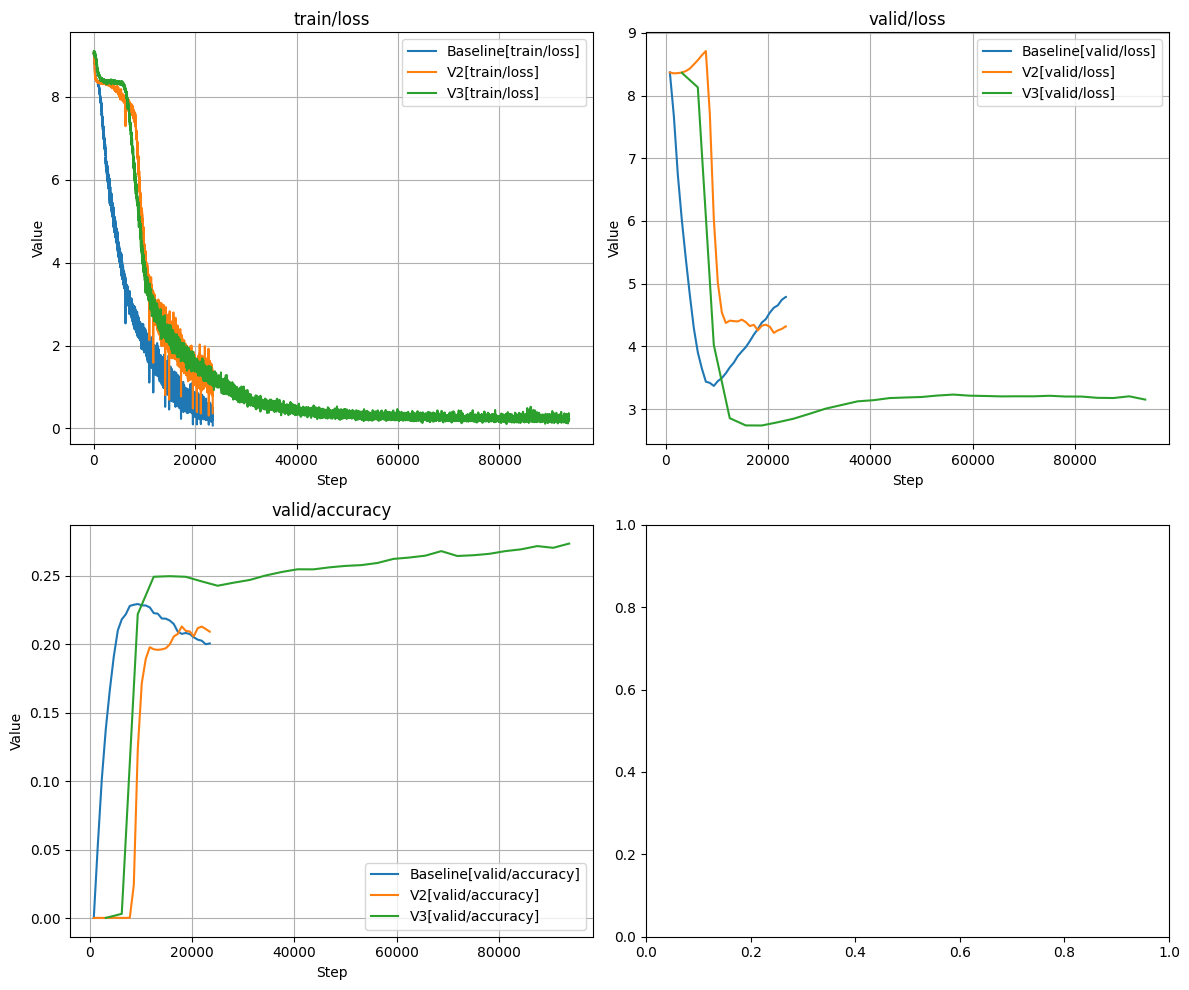

In [22]:
plot_metrics(
    # {
    #     "Mamba32": "/home/needpetrov/projects/zoology/runs/Mamba_2_layers__lr_0.0003__difficulty_32/default/events.out.tfevents.1777909991.butch.38525.0",
    #     "Mamba64": "/home/needpetrov/projects/zoology/runs/Mamba_2_layers__lr_0.0003__difficulty_64/default/events.out.tfevents.1777915111.butch.65246.0",
    #     "Attn32": "/home/needpetrov/projects/zoology/runs/MHA_h4_2_layers__lr_0.0003__difficulty_32/default/events.out.tfevents.1777915105.butch.65084.0",
    #     "Attn64": "/home/needpetrov/projects/zoology/runs/MHA_h4_2_layers__lr_0.0003__difficulty_64/default/events.out.tfevents.1777909986.butch.38386.0",
    # },
    {
        "Baseline": "/home/needpetrov/projects/zoology/runs/S4D_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778045289.butch.616956.0",
        "V2": "/home/needpetrov/projects/zoology/runs/Due_S4D_8_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778102570.butch.1610633.0",
        "V3": "/home/needpetrov/projects/zoology/runs/Tre_MoE_S4D_8A2_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778102680.butch.1611435.0",
    },
    keys=["train/loss", "valid/loss", "valid/accuracy", "train/router_entropy/mean"],
    align_steps=True,
)